In [ ]:
import os 

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

from IPython import display

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODELS
EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

MODEL_DIR = MODELS / "category_projection"

In [73]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [74]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [75]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [76]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.12.0+cu130
13.0
True
1


In [77]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

Device: cuda


In [78]:
dino = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14"
        )

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main


In [79]:
%load_ext autoreload
%autoreload 0

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, train_one_epoch, evaluate

from src.fine_tune.losses.category_head.combined_loss import CombinedLoss

git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
LOSSES = {
    "category_cont" : True,
    "preservation": True
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.5
}

NOTES = [
    "Removed chance for horizontal swapping in transforms as thats not a good case for some categories(metal-nut) where horizontal flip is actually an anomaly"
]

In [81]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = f"{timestamp}_category_model.pt"

In [82]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : 256,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,
        "model_normaliser": MODEL_NORMALISER,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    }
}

In [83]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.category_ids[i] for i in train_set.indices]
val_labels = [dataset.category_ids[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [84]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM, norm_type=MODEL_NORMALISER).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [85]:

results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

try:
    for epoch in tqdm(range(EPOCHS)):
        train_loss = train_one_epoch(model, [dino], train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, [dino], val_loader, criterion, device)

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss)
        }
        
        print(results.tail(1).to_string(
            index=False,
            header=(epoch==0)
        ) + "\n")

finally:
    if best_state is not None:
        checkpoint = {
            "model_state_dict" : best_state,
            "model_info" : MODEL_INFO,
        }
        torch.save(checkpoint, MODEL_DIR / MODEL_NAME)
        print(f"Best Model Saved (val_loss={best_val:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]

same=0.8238, different=0.0998, gap=0.7240
Gradient Norm: 0.130116161987339
Paramter change: 0.000999372685328126
same=0.8481, different=0.1258, gap=0.7223
Gradient Norm: 0.08973862599940786
Paramter change: 0.0007871308480389416
same=0.8595, different=0.1416, gap=0.7179
Gradient Norm: 0.07243423083192109
Paramter change: 0.0006810780614614487
same=0.8745, different=0.1523, gap=0.7221
Gradient Norm: 0.05726583096704882
Paramter change: 0.00061472796369344
same=0.8750, different=0.1589, gap=0.7161
Gradient Norm: 0.055477393985438335
Paramter change: 0.0005697370506823063
same=0.8875, different=0.1557, gap=0.7318
Gradient Norm: 0.0486943569067888
Paramter change: 0.0005301305209286511
same=0.8870, different=0.1492, gap=0.7378
Gradient Norm: 0.049741868274056376
Paramter change: 0.0005036339280195534
same=0.8936, different=0.1412, gap=0.7524
Gradient Norm: 0.04310724821444609
Paramter change: 0.000477822293760255
same=0.9021, different=0.1299, gap=0.7722
Gradient Norm: 0.03664638372456878


KeyboardInterrupt: 

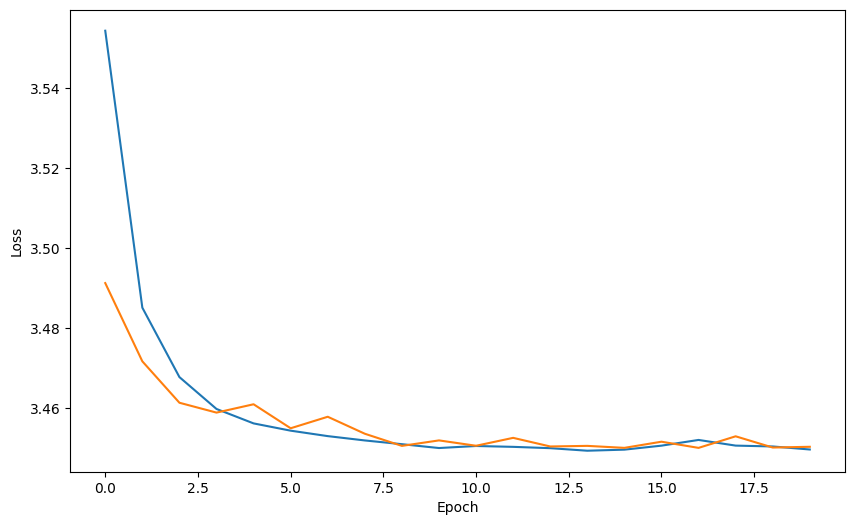

In [ ]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()